In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

In [6]:
project_path = Path.cwd().parent
data_path = project_path / 'data'
assert data_path.exists()

## Process ADCP bathymetry

In [7]:
def convert_yrday(yd, year):
    """Convert 'yrday_gmt' to datetime objects, now with the known year"""
    day_of_year = int(yd)
    fractional_day = yd - day_of_year
    start_of_year = pd.to_datetime(f'{year}-01-01')
    time_delta = pd.to_timedelta(fractional_day * 24, unit='h')
    return start_of_year + pd.Timedelta(days=day_of_year - 1) + time_delta

In [8]:
def process_adcp_bathy_time(ds: xr.Dataset):
    year = 1996
    times = pd.Series(ds['yrday_gmt'].values).apply(lambda x: convert_yrday(x, year)).values
    ds['time'] = ('unlimited', times)

In [9]:
ds = xr.load_dataset(data_path/'globec/netcdf' / 'bathy_ADCP.nc')

In [11]:
process_adcp_bathy_time(ds)

In [13]:
ds = ds.set_coords(['time', 'lat', 'lon'])
ds = ds.rename(dict(unlimited='record'))

In [15]:
ds

<xarray.Dataset> Size: 30MB
Dimensions:    (record: 27876)
Coordinates:
    lat        (record) float64 223kB 41.41 41.4 41.4 41.4 ... 41.49 41.5 41.51
    lon        (record) float64 223kB -71.35 -71.31 -71.29 ... -70.66 -70.67
    time       (record) datetime64[ns] 223kB 1996-01-09T17:48:12.038400 ... 1...
Dimensions without coordinates: record
Data variables:
    cruiseid   (record) |S513 14MB b'EN259' b'EN259' ... b'EN269' b'EN269'
    ship       (record) |S513 14MB b'Endeavor' b'Endeavor' ... b'Endeavor'
    yrday_gmt  (record) float64 223kB 9.742 9.745 9.749 ... 193.7 193.7 193.7
    depth_w    (record) float64 223kB 30.0 33.0 32.0 31.0 ... 22.0 23.0 22.0

In [17]:
# Add the 'units' attribute to the 'depth_w' variable
ds['depth_w'].attrs['units'] = 'meters'

In [18]:
import matplotlib.pyplot as pp
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable

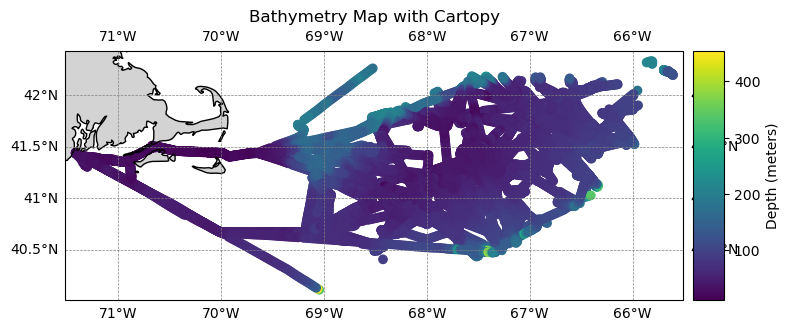

In [22]:
# Set the projection for the map
projection = ccrs.PlateCarree()

# Create the figure and axes with a Cartopy projection
# Create the figure and axes with a Cartopy projection
fig = pp.figure(figsize=(8, 6))  # Adjust figure size as needed
ax = fig.add_subplot(1, 1, 1, projection=projection)

# Scatter plot of bathymetry
# Scatter plot of bathymetry
scatter = ax.scatter(ds['lon'], ds['lat'], c=ds['depth_w'], cmap='viridis', transform=projection)

# Add coastlines and land features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5, color='gray')

# Set extent to focus on your data area
extent = [ds['lon'].min() - 0.1, ds['lon'].max() + 0.1,
          ds['lat'].min() - 0.1, ds['lat'].max() + 0.1]
ax.set_extent(extent)

# --- Using make_axes_locatable to control colorbar size and placement ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=pp.Axes)

# Create the colorbar on the new axes 'cax'
cbar = pp.colorbar(scatter, cax=cax, label=f"Depth ({ds['depth_w'].attrs.get('units', 'unknown')})")

ax.set_title("Bathymetry Map with Cartopy")
fig.tight_layout()

In [71]:
ds_nut = xr.load_dataset(data_path/'globec/netcdf/raw'/'nut_phyto.nc', mask_and_scale=True)

In [72]:
ds_nut

<xarray.Dataset> Size: 7MB
Dimensions:      (unlimited: 3926)
Dimensions without coordinates: unlimited
Data variables: (12/21)
    ID           (unlimited) |S513 2MB b'jan97' b'jan97' ... b'jun99' b'jun99'
    Month_name   (unlimited) |S513 2MB b'Jan' b'Jan' b'Jan' ... b'June' b'June'
    year         (unlimited) float64 31kB 1.997e+03 1.997e+03 ... 1.999e+03
    station_std  (unlimited) |S513 2MB b'3' b'3' b'3' b'4' ... b'38' b'38' b'38'
    lat          (unlimited) float64 31kB 40.53 40.53 40.53 ... 41.51 41.51
    lon          (unlimited) float64 31kB -68.44 -68.44 -68.44 ... -68.95 -68.95
    ...           ...
    chl_a        (unlimited) float64 31kB 0.16 0.81 0.88 0.71 ... 1.0 2.77 0.46
    phaeo        (unlimited) float64 31kB 0.31 0.78 0.73 0.55 ... 0.1 0.11 0.04
    NO3_NO2      (unlimited) float64 31kB 9.969e+36 9.969e+36 ... 0.06 0.06
    SiOH_4       (unlimited) float64 31kB 9.969e+36 9.969e+36 ... 0.0 0.0
    NH4          (unlimited) float64 31kB 9.969e+36 9.969e+36 ... 0.0 0.0
    PO4          (unlimited) float64 31kB 9.969e+36 9.969e+36 ... 0.14 0.04

In [73]:
def process_nut_phyto(ds):
    """Process the nutrient and phytoplankton dataset.

    This function orchestrates the steps to add a proper datetime coordinate,
    set relevant variables as coordinates, rename the main dimension, and
    assign units to the data variables.

    Parameters
    ----------
    ds : xarray.Dataset
        The input xarray Dataset containing nutrient and phytoplankton data.
        It is expected to have 'year', 'month', 'day', 'yrday_local', 'lat',
        'lon', 'depth', 'station_std', 'chl_a', 'phaeo', 'press', 'temp',
        'sal', 'flvolt', 'NH4', 'NO3_NO2', 'PO4', and 'SiOH_4' variables.

    Returns
    -------
    xarray.Dataset
        The processed xarray Dataset with a 'time' coordinate, 'lat', 'lon',
        'depth', and 'station_std' set as coordinates, the main dimension
        renamed to 'observation', and units added as attributes to the
        data variables.
    """
    ds = get_date_time(ds)
    ds = set_nut_phyto_coords(ds)
    set_unit_variables(ds)
    return ds

def get_date_time(ds):
    """Create a datetime coordinate from year, month, day, and yrday_local.

    This function converts the 'year', 'month', and 'day' variables into a base
    datetime object (midnight of that day) and then uses the fractional part
    of 'yrday_local' to add the time of day (hours, minutes, seconds) to
    create a 'time' coordinate in the Dataset. The original 'year', 'month',
    'day', 'yrday_local', and the original ambiguous 'time' variables are
    dropped from the Dataset.

    Parameters
    ----------
    ds : xarray.Dataset
        The input xarray Dataset containing 'year', 'month', 'day', and
        'yrday_local' variables.

    Returns
    -------
    None
        The input Dataset `ds` is modified in place by adding a 'time'
        coordinate and dropping the original time-related variables.

    array(['1997-01-14T12:00:00.000000000'], dtype='datetime64[ns]')
    """
    # Convert year, month, day to integers
    year_int = ds['year'].astype(int)
    month_int = ds['month'].astype(int)
    day_int = ds['day'].astype(int)

    # Create a base datetime object (midnight of that day)
    base_times = pd.to_datetime(dict(year=year_int, month=month_int, day=day_int))
    # Extract the fractional part of yrday_local (representing the time of day)
    fractional_day = ds['yrday_local'] - ds['yrday_local'].astype(int)
    # Convert the fractional day to total seconds
    seconds_in_day = fractional_day * 24 * 3600
    # Add the seconds to the base datetime to get the time of day
    final_times = base_times + pd.to_timedelta(seconds_in_day, unit='s')
    # Add the datetime coordinate to the Dataset
    ds['time'] = ('unlimited', final_times)
    # Drop the original time components (including the ambiguous 'time' variable)
    ds = ds.drop_vars(['year', 'month', 'day', 'yrday_local'])
    return ds


def set_nut_phyto_coords(ds):
    """Set standard coordinates for the nutrient and phytoplankton dataset.

    This function sets 'time', 'lat', 'lon', 'depth', and 'station_std' as
    coordinates of the input xarray Dataset and renames the 'unlimited'
    dimension to 'observation'.

    Parameters
    ----------
    ds : xarray.Dataset
        The input xarray Dataset. It is expected to have 'time', 'lat', 'lon',
        'depth', and 'station_std' as data variables and an 'unlimited'
        dimension.

    Returns
    -------
    None
        The input Dataset `ds` is modified in place by setting coordinates
        and renaming the dimension.

    Coordinates:
      * time         (record) datetime64[ns] 2000-01-01
      * lat          (record) float64 1.0
      * lon          (record) float64 2.0
      * depth        (record) float64 10.0
      * station_std  (record) <U1 'A'
    Dimensions without coordinates: record
    """
    # Set coordinates
    ds = ds.set_coords(['time', 'lat', 'lon', 'depth', 'station_std'])

    # Rename the 'unlimited' dimension
    ds = ds.rename({'unlimited': 'observation'})
    return ds

def set_unit_variables(ds):
    """Set standard units as attributes for key variables.

    This function adds 'units' as attributes to the 'chl_a', 'phaeo', 'depth',
    'lat', 'lon', 'NH4', 'NO3_NO2', 'PO4', 'press', 'sal', 'SiOH_4', and
    'temp' variables in the input xarray Dataset based on the provided
    data description.

    Parameters
    ----------
    ds : xarray.Dataset
        The input xarray Dataset containing the aforementioned data variables.

    Returns
    -------
    None
        The input Dataset `ds` is modified in place by adding 'units'
        attributes to the specified data variables.

    """
    # Add units as attributes (as done previously)
    ds['chl_a'].attrs['units'] = 'mg/m3'
    ds['phaeo'].attrs['units'] = 'mg/m3'
    ds['depth'].attrs['units'] = 'meters'
    ds['lat'].attrs['units'] = 'degrees_north'
    ds['lon'].attrs['units'] = 'degrees_east'
    ds['NH4'].attrs['units'] = 'µM'
    ds['NO3_NO2'].attrs['units'] = 'µM'
    ds['PO4'].attrs['units'] = 'µM'
    ds['press'].attrs['units'] = 'decibars'
    ds['sal'].attrs['units'] = 'practical salinity units'
    ds['SiOH_4'].attrs['units'] = 'µM'
    ds['temp'].attrs['units'] = 'Degrees Centigrade'
    ds['flvolt'].attrs['units'] = 'Volts'
    return ds

In [74]:
ds_nut = process_nut_phyto(ds_nut)

In [75]:
ds_nut

<xarray.Dataset> Size: 6MB
Dimensions:      (observation: 3926)
Coordinates:
    station_std  (observation) |S513 2MB b'3' b'3' b'3' ... b'38' b'38' b'38'
    lat          (observation) float64 31kB 40.53 40.53 40.53 ... 41.51 41.51
    lon          (observation) float64 31kB -68.44 -68.44 ... -68.95 -68.95
    time         (observation) datetime64[ns] 31kB 1997-01-14T01:41:57.120000...
    depth        (observation) float64 31kB 81.0 20.0 2.0 20.0 ... 40.0 20.0 2.0
Dimensions without coordinates: observation
Data variables:
    ID           (observation) |S513 2MB b'jan97' b'jan97' ... b'jun99' b'jun99'
    Month_name   (observation) |S513 2MB b'Jan' b'Jan' ... b'June' b'June'
    press        (observation) float64 31kB 81.32 22.37 2.495 ... 20.2 1.267
    temp         (observation) float64 31kB 11.6 7.014 7.007 ... 11.37 17.61
    sal          (observation) float64 31kB 34.18 32.25 32.25 ... 32.07 31.73
    flvolt       (observation) float64 31kB 0.178 0.732 0.446 ... 0.618 0.152
    chl_a        (observation) float64 31kB 0.16 0.81 0.88 ... 1.0 2.77 0.46
    phaeo        (observation) float64 31kB 0.31 0.78 0.73 ... 0.1 0.11 0.04
    NO3_NO2      (observation) float64 31kB 9.969e+36 9.969e+36 ... 0.06 0.06
    SiOH_4       (observation) float64 31kB 9.969e+36 9.969e+36 ... 0.0 0.0
    NH4          (observation) float64 31kB 9.969e+36 9.969e+36 ... 0.0 0.0
    PO4          (observation) float64 31kB 9.969e+36 9.969e+36 ... 0.14 0.04

In [76]:
df_nut = ds_nut.to_dataframe()
df_nut['station_std'] = df_nut.station_std.astype('str')
df_nut['ID'] = df_nut.ID.astype('str')
df_nut['Month_name'] = df_nut.Month_name.astype('str')

In [78]:
source_fill_val = df_nut.PO4.max()
target_fill_val = np.nan

In [82]:
df_nut.fillna(source_fill_val, inplace=True)

In [85]:
df_nut.replace(source_fill_val, np.nan, inplace=True)

In [86]:
df_nut.head()

,ID,Month_name,station_std,lat,lon,time,depth,press,temp,sal,flvolt,chl_a,phaeo,NO3_NO2,SiOH_4,NH4,PO4
observation,,,,,,,,,,,,,,,,,
0,jan97,Jan,3,40.530,-68.437,1997-01-14 01:41:57.120,81.0,81.316,11.597,34.179,0.178,0.16,0.31,NaN,NaN,NaN,NaN
1,jan97,Jan,3,40.530,-68.437,1997-01-14 01:41:57.120,20.0,22.373,7.014,32.247,0.732,0.81,0.78,NaN,NaN,NaN,NaN
2,jan97,Jan,3,40.530,-68.437,1997-01-14 01:41:57.120,2.0,2.495,7.007,32.246,0.446,0.88,0.73,NaN,NaN,NaN,NaN
3,jan97,Jan,4,40.997,-68.205,1997-01-14 09:29:57.120,20.0,20.293,6.910,32.160,0.461,0.71,0.55,NaN,NaN,NaN,NaN
4,jan97,Jan,4,40.997,-68.205,1997-01-14 09:29:57.120,2.0,1.921,6.899,32.158,0.377,0.57,0.57,NaN,NaN,NaN,NaN


In [87]:
df_nut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3926 entries, 0 to 3925
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ID           3926 non-null   object        
 1   Month_name   3926 non-null   object        
 2   station_std  3926 non-null   object        
 3   lat          3926 non-null   float64       
 4   lon          3926 non-null   float64       
 5   time         3926 non-null   datetime64[ns]
 6   depth        3926 non-null   float64       
 7   press        3251 non-null   float64       
 8   temp         3264 non-null   float64       
 9   sal          3260 non-null   float64       
 10  flvolt       3250 non-null   float64       
 11  chl_a        3040 non-null   float64       
 12  phaeo        2922 non-null   float64       
 13  NO3_NO2      3800 non-null   float64       
 14  SiOH_4       3800 non-null   float64       
 15  NH4          3502 non-null   float64       
 16  PO4   

In [88]:
df_nut.head()

,ID,Month_name,station_std,lat,lon,time,depth,press,temp,sal,flvolt,chl_a,phaeo,NO3_NO2,SiOH_4,NH4,PO4
observation,,,,,,,,,,,,,,,,,
0,jan97,Jan,3,40.530,-68.437,1997-01-14 01:41:57.120,81.0,81.316,11.597,34.179,0.178,0.16,0.31,NaN,NaN,NaN,NaN
1,jan97,Jan,3,40.530,-68.437,1997-01-14 01:41:57.120,20.0,22.373,7.014,32.247,0.732,0.81,0.78,NaN,NaN,NaN,NaN
2,jan97,Jan,3,40.530,-68.437,1997-01-14 01:41:57.120,2.0,2.495,7.007,32.246,0.446,0.88,0.73,NaN,NaN,NaN,NaN
3,jan97,Jan,4,40.997,-68.205,1997-01-14 09:29:57.120,20.0,20.293,6.910,32.160,0.461,0.71,0.55,NaN,NaN,NaN,NaN
4,jan97,Jan,4,40.997,-68.205,1997-01-14 09:29:57.120,2.0,1.921,6.899,32.158,0.377,0.57,0.57,NaN,NaN,NaN,NaN


In [90]:
df_nut.drop('Month_name', inplace=True, axis=1)

In [91]:
df_nut.to_parquet(data_path / 'globec' / 'preproc_df' / 'df_nut_phyto.pqt')

In [92]:
df_bath_adcp = ds.to_dataframe()

In [93]:
df_bath_adcp.head()

,cruiseid,ship,yrday_gmt,lat,lon,depth_w,time
record,,,,,,,
0,b'EN259',b'Endeavor',9.741806,41.4070,-71.3461,30.0,1996-01-09 17:48:12.038400
1,b'EN259',b'Endeavor',9.745278,41.4015,-71.3139,33.0,1996-01-09 17:53:12.019200
2,b'EN259',b'Endeavor',9.748762,41.3987,-71.2933,32.0,1996-01-09 17:58:13.036800
3,b'EN259',b'Endeavor',9.752222,41.3957,-71.2727,31.0,1996-01-09 18:03:11.980800
4,b'EN259',b'Endeavor',9.755694,41.3921,-71.2516,29.0,1996-01-09 18:08:11.961600


In [96]:
df_bath_adcp['cruiseid'] = df_bath_adcp.cruiseid.astype('str')
df_bath_adcp['ship'] = df_bath_adcp.ship.astype('str')

In [98]:
df_bath_adcp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27876 entries, 0 to 27875
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   cruiseid   27876 non-null  object        
 1   ship       27876 non-null  object        
 2   yrday_gmt  27876 non-null  float64       
 3   lat        27876 non-null  float64       
 4   lon        27876 non-null  float64       
 5   depth_w    27876 non-null  float64       
 6   time       27876 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 1.5+ MB


In [99]:
df_bath_adcp.describe()

,yrday_gmt,lat,lon,depth_w,time
count,27876.000000,27876.000000,27876.000000,27876.000000,27876
mean,104.365725,41.281448,-67.741842,70.536411,1996-04-13 08:46:38.677515776
min,9.741806,40.110200,-71.411700,12.000000,1996-01-09 17:48:12.038400
25%,62.580012,40.951975,-68.261125,49.000000,1996-03-02 13:55:13.015200
50%,105.330509,41.320850,-67.529300,68.000000,1996-04-14 07:55:55.977600
75%,150.256319,41.523100,-67.016575,80.000000,1996-05-29 06:09:05.983200
max,193.657697,42.331300,-65.608800,454.000000,1996-07-11 15:47:05.020800
std,51.833547,0.395361,1.097322,31.162683,NaN


In [100]:
df_bath_adcp.to_parquet(data_path / 'globec/preproc_df/df_bath_adcp.pqt')

### Processing Bongo

In [101]:
ds_bongo = xr.load_dataset(data_path / 'globec/netcdf/raw' / 'bongovols.nc')

In [103]:
ds_bongo

<xarray.Dataset> Size: 5MB
Dimensions:      (unlimited: 1843)
Dimensions without coordinates: unlimited
Data variables: (12/17)
    cruiseid     (unlimited) |S513 945kB b'AL9505' b'AL9505' ... b'OC341'
    year         (unlimited) float64 15kB 1.995e+03 1.995e+03 ... 1.999e+03
    cast         (unlimited) |S513 945kB b'1' b'2' b'3' ... b'77' b'78' b'79'
    station      (unlimited) |S513 945kB b'1' b'2' b'3' ... b'76' b'77' b'78'
    station_std  (unlimited) |S513 945kB b'1' b'2' b'3' ... b'79' b'36' b'80'
    day_local    (unlimited) float64 15kB 9.0 9.0 9.0 10.0 ... 26.0 26.0 26.0
    ...           ...
    depth        (unlimited) float64 15kB 76.0 62.0 87.0 53.0 ... 40.0 50.0 68.0
    raw_vol      (unlimited) float64 15kB 105.0 90.0 75.0 ... 38.0 132.0 223.0
    haul_factor  (unlimited) float64 15kB 0.6742 0.5067 0.4531 ... 0.9257 0.6494
    displ_vol    (unlimited) float64 15kB 71.0 46.0 34.0 ... 41.0 122.0 145.0
    region       (unlimited) |S513 945kB b'GBK' b'GBK' b'GBK' ... b'GBK' b'GBK'
    yrday_local  (unlimited) float64 15kB 129.0 129.0 129.0 ... 116.0 116.0